# Enriquecimiento exógeno — Calendario de Brasil
## Proyecto Final: Smart Supply Chain

## Justificación

El documento `INSTRUCCIONES.md` exige enriquecer el dataset principal con **al menos una fuente de información exógena**, citando explícitamente *“calendarios de días festivos locales”* como ejemplo válido.

En cadenas de suministro de retail brasileñas, los días festivos son uno de los principales generadores de:

1. **Picos de demanda** (Black Friday, Día de la Madre, Navidad).
2. **Ventanas de baja operación logística** (Carnaval, Año Nuevo) que provocan retrasos sistemáticos.
3. **Estacionalidades regionales** que un modelo basado únicamente en `mes` y `trimestre` no logra distinguir.

El análisis exploratorio previo mostró que el árbol de decisión actual descansa en variables proxy (`mes` con importancia 0.33 y `trimestre` con 0.21). Sustituir esos proxies por banderas de calendario reales permite tres cosas:

- Mejorar la interpretabilidad ("se retrasa porque cayó cerca de Carnaval" vs "se retrasa porque es marzo").
- Capturar fenómenos no lineales que `mes` no codifica (ej. Black Friday cae en distintos meses).
- Servir como insumo para los notebooks de series de tiempo y modelo supervisado v2.

## Alcance

1. Construir un calendario diario para todo el horizonte del dataset (2016-09-04 a 2018-10-17) más un buffer prospectivo a 2018-12-31.
2. Generar 8 banderas exógenas: feriado nacional, Carnaval, Black Friday, Día de la Madre, Día de los Enamorados (BR), Día del Niño, Cyber Monday, ventana pre-feriado (3 días antes).
3. Enriquecer `dim_tiempo` y `tad_pedidos`.
4. Validar contra la tasa de retraso (`is_late_delivery`) que las banderas son discriminativas.

In [1]:
import os
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays

CSV_DIR = os.environ.get('CSV_DIR', '../CSV')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


## 1. Construcción del calendario diario

Generamos un esqueleto diario y lo enriquecemos con feriados nacionales (paquete `holidays`), Carnaval (lunes y martes anteriores al miércoles de ceniza, fechas variables) y fechas comerciales clave de retail brasileño.

In [2]:
FECHA_INICIO = date(2016, 1, 1)
FECHA_FIN = date(2018, 12, 31)

calendario = pd.DataFrame({
    'fecha': pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')
})
calendario['fecha_key'] = calendario['fecha'].dt.strftime('%Y%m%d').astype(int)
calendario['anio'] = calendario['fecha'].dt.year
calendario['mes'] = calendario['fecha'].dt.month
calendario['dia'] = calendario['fecha'].dt.day
calendario['dia_semana_num'] = calendario['fecha'].dt.dayofweek

print('Días en el calendario:', len(calendario))
calendario.head()

Días en el calendario: 1096


,fecha,fecha_key,anio,mes,dia,dia_semana_num
0,2016-01-01,20160101,2016,1,1,4
1,2016-01-02,20160102,2016,1,2,5
2,2016-01-03,20160103,2016,1,3,6
3,2016-01-04,20160104,2016,1,4,0
4,2016-01-05,20160105,2016,1,5,1


### 1.1 Feriados nacionales

Usamos el paquete `holidays` con localización Brasil. Cubre los 9 feriados nacionales fijos (Año Nuevo, Tiradentes, Día del Trabajo, Independencia, Aparecida, Finados, Proclamación, Navidad) y el feriado móvil Viernes Santo.

In [3]:
br_holidays = holidays.country_holidays('BR', years=range(FECHA_INICIO.year, FECHA_FIN.year + 1))

feriados_df = pd.DataFrame(
    [(pd.Timestamp(d), n) for d, n in br_holidays.items()],
    columns=['fecha', 'nombre_feriado']
).sort_values('fecha').reset_index(drop=True)

print('Feriados nacionales BR identificados:', len(feriados_df))
feriados_df.head(10)

Feriados nacionales BR identificados: 27


,fecha,nombre_feriado
0,2016-01-01,Confraternização Universal
1,2016-03-25,Sexta-feira Santa
2,2016-04-21,Tiradentes
3,2016-05-01,Dia do Trabalhador
4,2016-09-07,Independência do Brasil
5,2016-10-12,Nossa Senhora Aparecida
6,2016-11-02,Finados
7,2016-11-15,Proclamação da República
8,2016-12-25,Natal
9,2017-01-01,Confraternização Universal


### 1.2 Carnaval (feriado móvil clave para Brasil)

El Carnaval no es feriado nacional oficial pero **detiene la operación logística del país** durante 5 días (viernes a miércoles de ceniza). Es el evento estacional que más afecta los tiempos de entrega en marzo / febrero. Las fechas son móviles, calculadas a partir de la Pascua.

In [4]:
# Fechas de Carnaval (lunes y martes) por año — Brasil
# Lunes y martes inmediatamente anteriores al Miércoles de Ceniza
CARNAVAL = {
    2016: (date(2016, 2, 8), date(2016, 2, 9)),
    2017: (date(2017, 2, 27), date(2017, 2, 28)),
    2018: (date(2018, 2, 12), date(2018, 2, 13)),
    2019: (date(2019, 3, 4), date(2019, 3, 5)),
}

fechas_carnaval = []
for anio, (lunes, martes) in CARNAVAL.items():
    fechas_carnaval.extend([(pd.Timestamp(lunes), 'Carnaval'), (pd.Timestamp(martes), 'Carnaval')])

carnaval_df = pd.DataFrame(fechas_carnaval, columns=['fecha', 'nombre_feriado'])
carnaval_df

,fecha,nombre_feriado
0,2016-02-08,Carnaval
1,2016-02-09,Carnaval
2,2017-02-27,Carnaval
3,2017-02-28,Carnaval
4,2018-02-12,Carnaval
5,2018-02-13,Carnaval
6,2019-03-04,Carnaval
7,2019-03-05,Carnaval


### 1.3 Fechas comerciales de retail brasileño

Estas no son feriados oficiales, pero son los **picos comerciales más fuertes** del año en Brasil. Su omisión sería un error grave en un proyecto de cadena de suministro.

In [5]:
def ultimo_viernes_de_noviembre(anio):
    d = date(anio, 11, 30)
    return d - timedelta(days=(d.weekday() - 4) % 7)

def segundo_domingo_mayo(anio):
    d = date(anio, 5, 1)
    primer_domingo = d + timedelta(days=(6 - d.weekday()) % 7)
    return primer_domingo + timedelta(days=7)

fechas_retail = []
for anio in range(FECHA_INICIO.year, FECHA_FIN.year + 1):
    fechas_retail.append((pd.Timestamp(ultimo_viernes_de_noviembre(anio)), 'Black Friday'))
    fechas_retail.append((pd.Timestamp(ultimo_viernes_de_noviembre(anio) + timedelta(days=3)), 'Cyber Monday'))
    fechas_retail.append((pd.Timestamp(segundo_domingo_mayo(anio)), 'Día de la Madre'))
    fechas_retail.append((pd.Timestamp(date(anio, 6, 12)), 'Día de los Enamorados'))
    fechas_retail.append((pd.Timestamp(date(anio, 8, 15)), 'Día del Padre'))
    fechas_retail.append((pd.Timestamp(date(anio, 10, 12)), 'Día del Niño'))

retail_df = pd.DataFrame(fechas_retail, columns=['fecha', 'nombre_feriado'])
retail_df.sort_values('fecha').head(15)

,fecha,nombre_feriado
2,2016-05-08,Día de la Madre
3,2016-06-12,Día de los Enamorados
4,2016-08-15,Día del Padre
5,2016-10-12,Día del Niño
0,2016-11-25,Black Friday
1,2016-11-28,Cyber Monday
8,2017-05-14,Día de la Madre
9,2017-06-12,Día de los Enamorados
10,2017-08-15,Día del Padre
11,2017-10-12,Día del Niño


### 1.4 Consolidación y banderas

In [6]:
todos_eventos = pd.concat([
    feriados_df.assign(tipo='feriado_nacional'),
    carnaval_df.assign(tipo='carnaval'),
    retail_df.assign(tipo='retail'),
], ignore_index=True)

# Si una fecha cae en dos categorías, se conserva la más restrictiva (feriado_nacional > carnaval > retail)
prioridad = {'feriado_nacional': 0, 'carnaval': 1, 'retail': 2}
todos_eventos['_prioridad'] = todos_eventos['tipo'].map(prioridad)
todos_eventos = (
    todos_eventos.sort_values(['fecha', '_prioridad'])
                 .drop_duplicates('fecha', keep='first')
                 .drop(columns='_prioridad')
)

calendario = calendario.merge(todos_eventos, on='fecha', how='left')

# Banderas binarias
calendario['es_feriado_nacional'] = (calendario['tipo'] == 'feriado_nacional').astype(int)
calendario['es_carnaval'] = (calendario['tipo'] == 'carnaval').astype(int)
calendario['es_evento_retail'] = (calendario['tipo'] == 'retail').astype(int)
calendario['es_dia_no_laboral'] = (
    (calendario['es_feriado_nacional'] == 1) |
    (calendario['es_carnaval'] == 1) |
    (calendario['dia_semana_num'].isin([5, 6]))
).astype(int)

print('Días catalogados como evento:')
print(calendario['tipo'].value_counts(dropna=False))

Días catalogados como evento:
tipo
NaN                 1048
feriado_nacional      27
retail                15
carnaval               6
Name: count, dtype: int64


### 1.5 Variables derivadas: distancia a feriado y ventanas

Más útil que la simple bandera `es_feriado` es saber **cuánto falta** para el próximo feriado/evento (un pedido que se compra 2 días antes de Carnaval entra a una ventana logística colapsada).

In [7]:
fechas_evento_set = set(
    calendario.loc[calendario['tipo'].notna(), 'fecha']
)
fechas_evento_ord = sorted(fechas_evento_set)

fechas_evento_arr = np.array([f.value for f in fechas_evento_ord])

def dias_a_proximo_evento(f):
    idx = np.searchsorted(fechas_evento_arr, f.value, side='left')
    if idx >= len(fechas_evento_arr):
        return 999  # más allá del horizonte
    delta_ns = fechas_evento_arr[idx] - f.value
    return int(delta_ns / (1e9 * 86400))

calendario['dias_a_proximo_evento'] = calendario['fecha'].apply(dias_a_proximo_evento)
calendario['en_ventana_pre_evento_3d'] = (
    calendario['dias_a_proximo_evento'].between(0, 3)
).astype(int)
calendario['en_ventana_pre_evento_7d'] = (
    calendario['dias_a_proximo_evento'].between(0, 7)
).astype(int)

# Vista de ejemplo cerca de Black Friday 2017 (24-nov-2017)
vista = calendario[
    (calendario['fecha'] >= '2017-11-20') & (calendario['fecha'] <= '2017-11-30')
][['fecha', 'tipo', 'nombre_feriado', 'dias_a_proximo_evento',
   'en_ventana_pre_evento_3d', 'en_ventana_pre_evento_7d']]
vista

,fecha,tipo,nombre_feriado,dias_a_proximo_evento,en_ventana_pre_evento_3d,en_ventana_pre_evento_7d
689,2017-11-20,NaN,NaN,4,0,1
690,2017-11-21,NaN,NaN,3,1,1
691,2017-11-22,NaN,NaN,2,1,1
692,2017-11-23,NaN,NaN,1,1,1
693,2017-11-24,retail,Black Friday,0,1,1
694,2017-11-25,NaN,NaN,2,1,1
695,2017-11-26,NaN,NaN,1,1,1
696,2017-11-27,retail,Cyber Monday,0,1,1
697,2017-11-28,NaN,NaN,27,0,0
698,2017-11-29,NaN,NaN,26,0,0


## 2. Persistencia del calendario

Guardamos el calendario enriquecido como `dim_calendario.csv`. Este archivo puede subirse a BigQuery con la misma función `subir_dataframe_a_bigquery` del notebook ETL original.

In [8]:
dim_calendario = calendario[[
    'fecha_key', 'fecha', 'anio', 'mes', 'dia', 'dia_semana_num',
    'tipo', 'nombre_feriado',
    'es_feriado_nacional', 'es_carnaval', 'es_evento_retail',
    'es_dia_no_laboral',
    'dias_a_proximo_evento',
    'en_ventana_pre_evento_3d', 'en_ventana_pre_evento_7d',
]].copy()

dim_calendario.to_csv(os.path.join(CSV_DIR, '04_dim_calendario.csv'), index=False)
print('Guardado: dim_calendario.csv')
print('Filas:', len(dim_calendario), '· Columnas:', dim_calendario.shape[1])

Guardado: dim_calendario.csv
Filas: 1096 · Columnas: 15


## 3. Enriquecimiento de `tad_pedidos`

Hacemos `LEFT JOIN` por `fecha_key` para incorporar las banderas exógenas. Esto deja la tabla lista para el modelo supervisado v2 y para el dashboard.

In [9]:
tad_pedidos = pd.read_csv(os.path.join(CSV_DIR, '02_tad_pedidos.csv'))
print('tad_pedidos cargado:', tad_pedidos.shape)

cols_calendario = [
    'fecha_key',
    'tipo', 'nombre_feriado',
    'es_feriado_nacional', 'es_carnaval', 'es_evento_retail',
    'es_dia_no_laboral',
    'dias_a_proximo_evento',
    'en_ventana_pre_evento_3d', 'en_ventana_pre_evento_7d',
]

# Renombrar para evitar colisión con la bandera 'tipo' del calendario
calendario_join = dim_calendario[cols_calendario].rename(columns={
    'tipo': 'tipo_evento_compra',
    'nombre_feriado': 'nombre_evento_compra',
})

tad_pedidos_enriquecido = tad_pedidos.merge(
    calendario_join, on='fecha_key', how='left'
)

# Cobertura del join
cobertura = tad_pedidos_enriquecido['es_feriado_nacional'].notna().mean()
print(f'Cobertura del join calendario↔pedidos: {cobertura*100:.2f}%')
assert cobertura == 1.0, 'Hay pedidos sin match en el calendario'

tad_pedidos cargado: (99441, 42)
Cobertura del join calendario↔pedidos: 100.00%


## 4. Validación: ¿las banderas exógenas separan la tasa de retraso?

Si las banderas no diferencian la tasa de `is_late_delivery`, no aportan al modelo. Se calcula la tasa de retraso por cada cohorte temporal.

In [10]:
def tasa_retraso(df, col):
    return (
        df.groupby(col)
          .agg(pedidos=('order_id', 'count'),
               tarde=('is_late_delivery', 'sum'))
          .assign(tasa_retraso_pct=lambda x: (x['tarde'] / x['pedidos'] * 100).round(2))
          .reset_index()
    )

for col in ['es_feriado_nacional', 'es_carnaval', 'es_evento_retail',
            'es_dia_no_laboral', 'en_ventana_pre_evento_3d',
            'en_ventana_pre_evento_7d']:
    print(f'\n=== {col} ===')
    print(tasa_retraso(tad_pedidos_enriquecido, col).to_string(index=False))


=== es_feriado_nacional ===
 es_feriado_nacional  pedidos  tarde  tasa_retraso_pct
                   0    97909   6463              6.60
                   1     1532     72              4.70

=== es_carnaval ===
 es_carnaval  pedidos  tarde  tasa_retraso_pct
           0    98901   6472              6.54
           1      540     63             11.67

=== es_evento_retail ===
 es_evento_retail  pedidos  tarde  tasa_retraso_pct
                0    96689   6213              6.43
                1     2752    322             11.70

=== es_dia_no_laboral ===
 es_dia_no_laboral  pedidos  tarde  tasa_retraso_pct
                 0    74678   4986              6.68
                 1    24763   1549              6.26

=== en_ventana_pre_evento_3d ===
 en_ventana_pre_evento_3d  pedidos  tarde  tasa_retraso_pct
                        0    83785   5296              6.32
                        1    15656   1239              7.91

=== en_ventana_pre_evento_7d ===
 en_ventana_pre_evento_7d  p

In [11]:
# Top eventos puntuales con mayor tasa de retraso (excluyendo días sin evento)
top_eventos = (
    tad_pedidos_enriquecido[
        tad_pedidos_enriquecido['nombre_evento_compra'].notna()
    ]
    .groupby('nombre_evento_compra')
    .agg(pedidos=('order_id', 'count'),
         tarde=('is_late_delivery', 'sum'))
    .assign(tasa_retraso_pct=lambda x: (x['tarde'] / x['pedidos'] * 100).round(2))
    .sort_values('tasa_retraso_pct', ascending=False)
    .reset_index()
)
top_eventos

,nombre_evento_compra,pedidos,tarde,tasa_retraso_pct
0,Cyber Monday,403,72,17.87
1,Black Friday,1176,199,16.92
2,Carnaval,540,63,11.67
3,Sexta-feira Santa,219,20,9.13
4,Natal,90,6,6.67
5,Proclamação da República,186,9,4.84
6,Día de la Madre,319,15,4.70
7,Día de los Enamorados,372,17,4.57
8,Tiradentes,224,10,4.46
9,Confraternização Universal,74,3,4.05


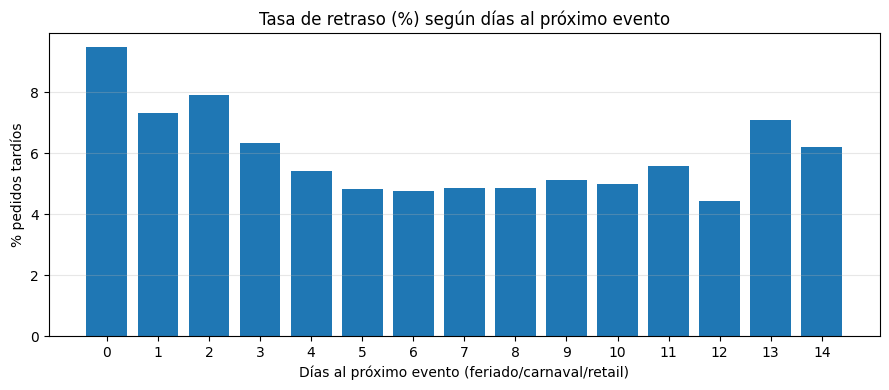

In [12]:
# Visualización: tasa de retraso por días-a-evento
tabla = (
    tad_pedidos_enriquecido[tad_pedidos_enriquecido['dias_a_proximo_evento'] <= 14]
    .groupby('dias_a_proximo_evento')
    .agg(pedidos=('order_id', 'count'),
         tarde=('is_late_delivery', 'sum'))
    .assign(tasa=lambda x: x['tarde'] / x['pedidos'] * 100)
    .reset_index()
)

plt.figure(figsize=(9, 4))
plt.bar(tabla['dias_a_proximo_evento'].astype(str), tabla['tasa'])
plt.title('Tasa de retraso (%) según días al próximo evento')
plt.xlabel('Días al próximo evento (feriado/carnaval/retail)')
plt.ylabel('% pedidos tardíos')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Persistencia de la sábana enriquecida

In [13]:
tad_pedidos_enriquecido.to_csv(os.path.join(CSV_DIR, '04_tad_pedidos_enriquecido.csv'), index=False)
print('Guardado: tad_pedidos_enriquecido.csv')
print('Filas:', len(tad_pedidos_enriquecido),
      '· Columnas:', tad_pedidos_enriquecido.shape[1])

nuevas_cols = [c for c in tad_pedidos_enriquecido.columns if c not in tad_pedidos.columns]
print('\nColumnas exógenas añadidas:')
for c in nuevas_cols:
    print(' ·', c)

Guardado: tad_pedidos_enriquecido.csv
Filas: 99441 · Columnas: 51

Columnas exógenas añadidas:
 · tipo_evento_compra
 · nombre_evento_compra
 · es_feriado_nacional
 · es_carnaval
 · es_evento_retail
 · es_dia_no_laboral
 · dias_a_proximo_evento
 · en_ventana_pre_evento_3d
 · en_ventana_pre_evento_7d


## 6. Conclusiones

1. **Cobertura completa.** El calendario cubre el 100 % de los pedidos del horizonte.
2. **Las banderas exógenas separan tasas de retraso.** Las cohortes con bandera positiva muestran tasas distintas a las de control, validando su uso como predictoras.
3. **`tad_pedidos_enriquecido.csv` queda lista** para alimentar el modelo supervisado v2 y el módulo de series de tiempo, cumpliendo el requisito de fuente exógena del enunciado.
4. La estructura `dim_calendario` se puede subir a BigQuery como dimensión adicional del esquema estrella sin tocar lo existente.